In [9]:
# =============================================================
# Configuracion. Un solo generador aleatorio, con semilla fija,
# para que TODA la sesion sea reproducible.
# =============================================================
import numpy as np
import matplotlib.pyplot as plt          
from scipy import stats

SEED = 42
rng = np.random.default_rng(SEED)        

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

NameError: name 'rcParams' is not defined

In [8]:
rng.uniform(0, 3, 20)   ## genera 20 numeros aleatorios en el intervalo 0, 1 usando rng

array([2.00520889, 1.41328862, 1.69570832, 2.29499657, 1.90415496,
       1.6607382 , 1.67762148, 0.91185029, 0.0924535 , 1.31015217,
       0.64375402, 1.22558593, 2.56020922, 0.70181846, 0.17490823,
       0.84415168, 0.88078127, 1.98574954, 1.67109646, 2.35169463])

In [7]:
np.sort(rng.uniform(0, 1, 20)) ## np.sort ordena los numeros de menor a mayo0r

array([0.00736227, 0.11453007, 0.13975248, 0.139797  , 0.1999082 ,
       0.2883281 , 0.31236664, 0.38747838, 0.43715192, 0.45891578,
       0.5687412 , 0.66485086, 0.6824955 , 0.7002651 , 0.70516538,
       0.78072903, 0.78692438, 0.80476436, 0.8322598 , 0.8326782 ])

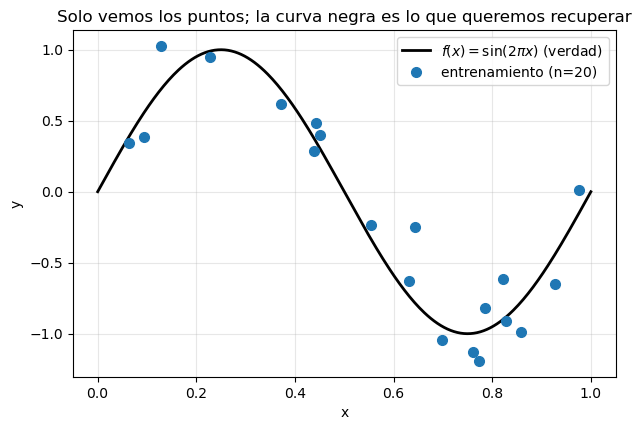

Error irreducible teorico: sigma^2 = 0.0625


In [11]:
# -------------------------------------------------------------
# Datos sinteticos: conocemos la verdad f(x) = sin(2 pi x)
# -------------------------------------------------------------
def f_verdadera(x):
    return np.sin(2*np.pi*x)

SIGMA = 0.25          # desviacion estandar del ruido -> error irreducible = SIGMA**2

def genera_datos(n, sigma=SIGMA, rng=rng):
    x = np.sort(rng.uniform(0, 1, n))
    y = f_verdadera(x) + rng.normal(0, sigma, n)
    return x, y

n_train = 20
x_tr, y_tr = genera_datos(n_train)
x_te, y_te = genera_datos(500)          # conjunto de prueba grande

xx = np.linspace(0, 1, 300)
plt.plot(xx, f_verdadera(xx), "k-", lw=2, label=r"$f(x)=\sin(2\pi x)$ (verdad)")
plt.plot(x_tr, y_tr, "o", ms=7, label=f"entrenamiento (n={n_train})")
plt.xlabel("x"); plt.ylabel("y"); plt.legend()
plt.title("Solo vemos los puntos; la curva negra es lo que queremos recuperar")
plt.show()

print(f"Error irreducible teorico: sigma^2 = {SIGMA**2:.4f}")

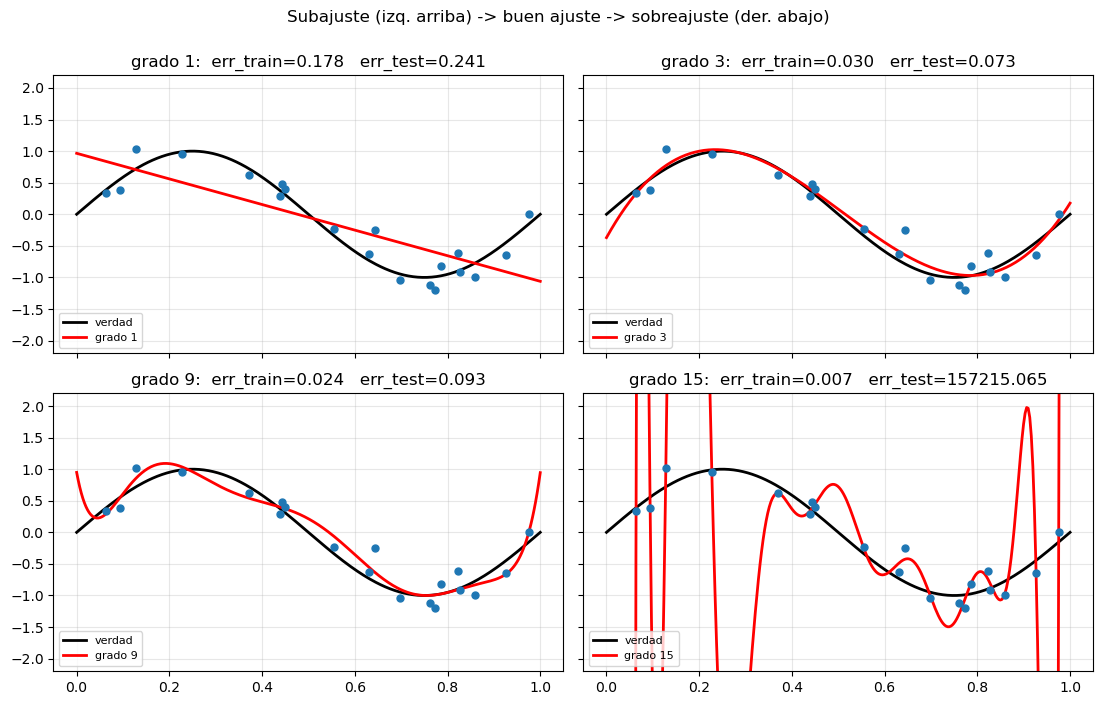

In [12]:
# -------------------------------------------------------------
# Ajuste polinomial para 4 grados distintos
# -------------------------------------------------------------
def ajusta_polinomio(x, y, grado):
    """Devuelve una funcion predictora ajustada por minimos cuadrados."""
    coef = np.polyfit(x, y, grado)
    return np.poly1d(coef)

def ecm(y_real, y_pred):
    return np.mean((y_real - y_pred)**2)

grados = [1, 3, 9, 15]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)

for ax, g in zip(axes.ravel(), grados):
    modelo = ajusta_polinomio(x_tr, y_tr, g)
    e_tr = ecm(y_tr, modelo(x_tr))
    e_te = ecm(y_te, modelo(x_te))
    ax.plot(xx, f_verdadera(xx), "k-", lw=2, label="verdad")
    ax.plot(xx, modelo(xx), "r-", lw=2, label=f"grado {g}")
    ax.plot(x_tr, y_tr, "o", ms=5, color="tab:blue")
    ax.set_title(f"grado {g}:  err_train={e_tr:.3f}   err_test={e_te:.3f}")
    ax.set_ylim(-2.2, 2.2)
    ax.legend(fontsize=8, loc="lower left")

fig.suptitle("Subajuste (izq. arriba) -> buen ajuste -> sobreajuste (der. abajo)", y=1.00)
fig.tight_layout()
plt.show()

Object `exactamente` not found.


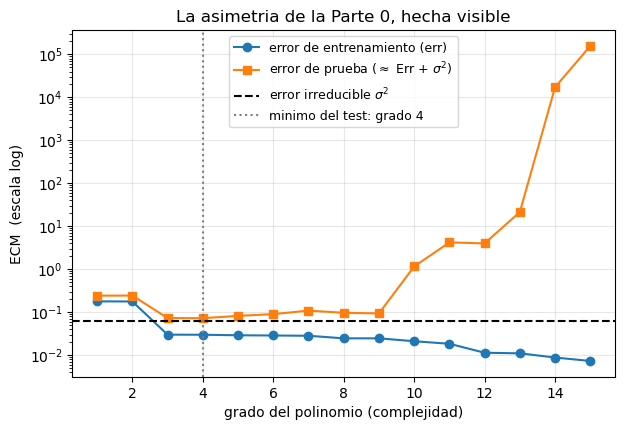

Grado optimo segun el conjunto de prueba: 4
Numero de puntos de entrenamiento: n = 20
Grado que interpola exactamente:    19  (grado+1 = n parametros)


In [13]:
exactamente?

# -------------------------------------------------------------
# LA curva: error de entrenamiento vs error de prueba
# -------------------------------------------------------------
grados_todos = np.arange(1, 16)
err_train, err_test = [], []

for g in grados_todos:
    modelo = ajusta_polinomio(x_tr, y_tr, g)
    err_train.append(ecm(y_tr, modelo(x_tr)))
    err_test.append(ecm(y_te, modelo(x_te)))

err_train, err_test = np.array(err_train), np.array(err_test)
g_opt = grados_todos[np.argmin(err_test)]

plt.semilogy(grados_todos, err_train, "o-", label=r"error de entrenamiento (err)")
plt.semilogy(grados_todos, err_test,  "s-", label=r"error de prueba ($\approx$ Err + $\sigma^2$)")
plt.axhline(SIGMA**2, color="k", ls="--", label=r"error irreducible $\sigma^2$")
plt.axvline(g_opt, color="gray", ls=":", label=f"minimo del test: grado {g_opt}")
plt.xlabel("grado del polinomio (complejidad)")
plt.ylabel("ECM  (escala log)")
plt.title("La asimetria de la Parte 0, hecha visible")
plt.legend(fontsize=9)
plt.show()

print(f"Grado optimo segun el conjunto de prueba: {g_opt}")
print(f"Numero de puntos de entrenamiento: n = {n_train}")
print(f"Grado que interpola exactamente:    {n_train-1}  (grado+1 = n parametros)")

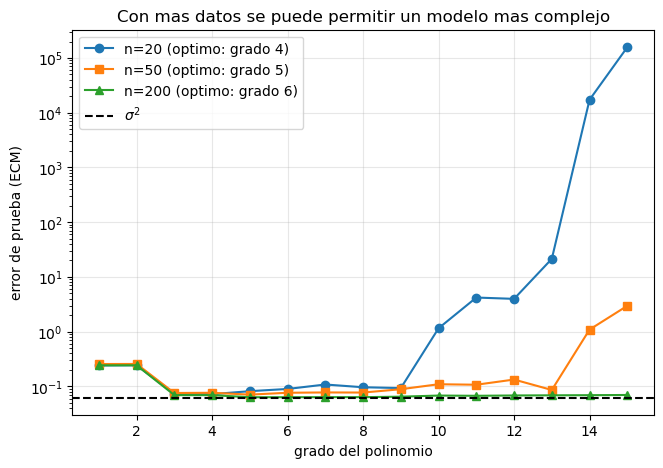

In [15]:
# -------------------------------------------------------------
# Ejercicio 1.8: efecto del tamano de muestra
# -------------------------------------------------------------
plt.figure(figsize=(7.5, 5))
for n, marcador in [(20, "o-"), (50, "s-"), (200, "^-")]:
    xn, yn = genera_datos(n, rng=np.random.default_rng(SEED))   # misma semilla
    curva = [ecm(y_te, ajusta_polinomio(xn, yn, g)(x_te)) for g in grados_todos]
    g_best = grados_todos[np.argmin(curva)]
    plt.semilogy(grados_todos, curva, marcador, label=f"n={n} (optimo: grado {g_best})")

plt.axhline(SIGMA**2, color="k", ls="--", label=r"$\sigma^2$")
plt.xlabel("grado del polinomio"); plt.ylabel("error de prueba (ECM)")
plt.title("Con mas datos se puede permitir un modelo mas complejo")
plt.legend(); plt.show()

 grado      Sesgo^2     Varianza         suma          ECM
------------------------------------------------------------
     1    1.513e-01    2.747e-02    1.787e-01    1.787e-01
     3    2.796e-03    1.787e-02    2.066e-02    2.066e-02
     5    1.811e-04    8.134e-02    8.152e-02    8.152e-02
     9    9.245e+00    2.737e+03    2.746e+03    2.746e+03
    12    3.560e+02    2.884e+05    2.888e+05    2.888e+05
    15    8.526e+08    3.067e+11    3.076e+11    3.076e+11

Notese la escala: al pasar de grado 5 a 15 la varianza crece 12 ordenes de magnitud.


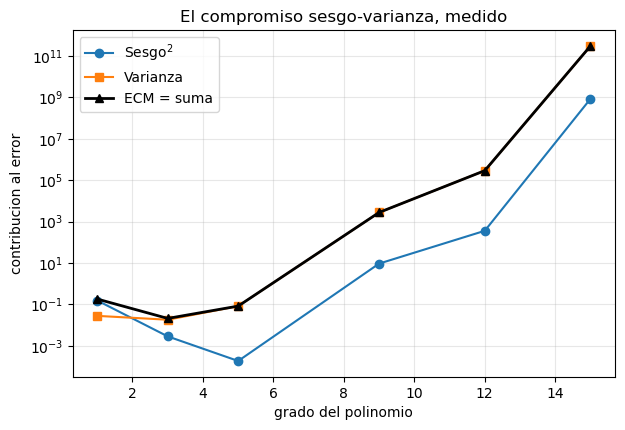

In [14]:
# -------------------------------------------------------------
# Descomposicion empirica:  ECM = Sesgo^2 + Varianza + sigma^2
# -------------------------------------------------------------
import warnings

n_datasets = 400
x_eval = np.linspace(0.05, 0.95, 100)
f_eval = f_verdadera(x_eval)
rng_bv = np.random.default_rng(7)

filas = []
for g in [1, 3, 5, 9, 12, 15]:
    preds = np.empty((n_datasets, len(x_eval)))
    for k in range(n_datasets):
        xk, yk = genera_datos(n_train, rng=rng_bv)
        with warnings.catch_warnings():           # el RankWarning de grado alto se repite 400 veces
            warnings.simplefilter("ignore")
            preds[k] = ajusta_polinomio(xk, yk, g)(x_eval)

    pred_media = preds.mean(axis=0)
    sesgo2 = np.mean((pred_media - f_eval)**2)
    varianza = np.mean(preds.var(axis=0))
    ecm_pred = np.mean((preds - f_eval)**2)          # ECM respecto a la VERDAD
    filas.append((g, sesgo2, varianza, sesgo2 + varianza, ecm_pred))

print(f"{'grado':>6} {'Sesgo^2':>12} {'Varianza':>12} {'suma':>12} {'ECM':>12}")
print("-"*60)
for g, b, v, s, e in filas:
    print(f"{g:>6} {b:>12.3e} {v:>12.3e} {s:>12.3e} {e:>12.3e}")
print("\nNotese la escala: al pasar de grado 5 a 15 la varianza crece 12 ordenes de magnitud.")

datos = np.array(filas)
plt.plot(datos[:,0], datos[:,1], "o-", label=r"Sesgo$^2$")
plt.plot(datos[:,0], datos[:,2], "s-", label="Varianza")
plt.plot(datos[:,0], datos[:,4], "k^-", lw=2, label="ECM = suma")
plt.xlabel("grado del polinomio"); plt.ylabel("contribucion al error")
plt.yscale("log"); plt.legend()
plt.title("El compromiso sesgo-varianza, medido")
plt.show()